In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 65.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 25.6MB/s]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data = pd.read_csv("/content/game_of_thrones_train.csv", index_col='S.No')
data_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')


In [ ]:
data.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


In [ ]:
numeric_columns = ['dateOfBirth', 'age']
for column in numeric_columns:
    if data[column].isna().sum() > 0:
        data[column].fillna(data[column].median(), inplace=True)
    if data_test[column].isna().sum() > 0:
        data_test[column].fillna(data_test[column].median(), inplace=True)


<ipython-input-6-92ea4c61235e>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].median(), inplace=True)
<ipython-input-6-92ea4c61235e>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
categorical_columns = ['title', 'culture', 'house', 'spouse']
for column in categorical_columns:
    if data[column].isna().sum() > 0:
        data[column].fillna('Unknown', inplace=True)
    if data_test[column].isna().sum() > 0:
        data_test[column].fillna('Unknown', inplace=True)
print(data[categorical_columns].isna().sum())
print(data_test[categorical_columns].isna().sum())


title      0
culture    0
house      0
spouse     0
dtype: int64
title      0
culture    0
house      0
spouse     0
dtype: int64


<ipython-input-7-d0e366bcd94d>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna('Unknown', inplace=True)
<ipython-input-7-d0e366bcd94d>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [ ]:
bool_columns = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble']
for column in bool_columns:
    if data[column].isna().sum() > 0:
        data[column].fillna(False, inplace=True)
    if data_test[column].isna().sum() > 0:
        data_test[column].fillna(False, inplace=True)
print(data[bool_columns].isna().sum())
print(data_test[bool_columns].isna().sum())


isAliveMother    0
isAliveFather    0
isAliveHeir      0
isAliveSpouse    0
isMarried        0
isNoble          0
dtype: int64
isAliveMother    0
isAliveFather    0
isAliveHeir      0
isAliveSpouse    0
isMarried        0
isNoble          0
dtype: int64


<ipython-input-8-a8aefefdb9ad>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(False, inplace=True)
<ipython-input-8-a8aefefdb9ad>:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data[column].fillna(False, inplace=True)
<ipython-input-8-a8aefefdb9ad>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Seri

In [ ]:
data['has_mother'] = data['mother'].notna().astype(int)
data['has_father'] = data['father'].notna().astype(int)
data['has_heir'] = data['heir'].notna().astype(int)
data['has_spouse'] = data['spouse'].notna().astype(int)

data_test['has_mother'] = data_test['mother'].notna().astype(int)
data_test['has_father'] = data_test['father'].notna().astype(int)
data_test['has_heir'] = data_test['heir'].notna().astype(int)
data_test['has_spouse'] = data_test['spouse'].notna().astype(int)



nan_summary_after = data_test.isna().sum()
print("Количество NaN значений после обработки:")
print(nan_summary_after)
data_test

Количество NaN значений после обработки:
name                  0
title                 0
male                  0
culture               0
dateOfBirth           0
mother              386
father              385
heir                387
house                 0
spouse                0
book1                 0
book2                 0
book3                 0
book4                 0
book5                 0
isAliveMother         0
isAliveFather         0
isAliveHeir           0
isAliveSpouse         0
isMarried             0
isNoble               0
age                   0
numDeadRelations      0
popularity            0
has_mother            0
has_father            0
has_heir              0
has_spouse            0
dtype: int64


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,has_mother,has_father,has_heir,has_spouse
S.No,,,,,,,,,,,,,,,,,,,,,
1558,Melissa Blackwood,Unknown,0,Unknown,156.0,NaN,NaN,NaN,House Blackwood,Unknown,...,False,0,0,100.0,0,0.050167,0,0,0,1
1559,Melisandre,Unknown,0,Asshai,267.0,NaN,NaN,NaN,R'hllor,Unknown,...,False,0,0,32.0,0,0.745819,0,0,0,1
1560,Merrit,Unknown,0,Unknown,267.0,NaN,NaN,NaN,Brotherhood without banners,Unknown,...,False,0,0,32.0,0,0.010033,0,0,0,1
1561,Meryn Trant,Ser,1,Unknown,267.0,NaN,NaN,NaN,House Trant,Unknown,...,False,0,1,32.0,0,0.220736,0,0,0,1
1562,Merrett Frey,Unknown,1,Riverlands,262.0,NaN,NaN,NaN,House Frey,Mariya Darry,...,1.0,1,0,38.0,0,0.434783,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,Luwin,Unknown,1,Westeros,267.0,NaN,NaN,NaN,House Stark,Unknown,...,False,0,0,32.0,0,0.351171,0,0,0,1
1943,Reek,Unknown,1,Unknown,267.0,NaN,NaN,NaN,House Bolton,Unknown,...,False,0,0,32.0,0,0.096990,0,0,0,1
1944,Symeon Star-Eyes,Unknown,1,Unknown,267.0,NaN,NaN,NaN,Unknown,Unknown,...,False,0,0,32.0,0,0.030100,0,0,0,1


In [ ]:
data = data.drop(columns=['mother', 'father', 'heir', 'spouse'])
data_test = data_test.drop(columns=['mother', 'father', 'heir', 'spouse'])


In [ ]:
data['isPopular'] = (data['popularity'] > 0.5).astype(int)
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)

data_test['isPopular'] = (data_test['popularity'] > 0.5).astype(int)
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)


In [ ]:
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari', 'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
}


In [ ]:
for target, variants in cult.items():
  for variant in variants:
    data['culture'] = data['culture'].replace(variants, target)
    data_test['culture'] = data_test['culture'].replace(variants, target)




In [ ]:
data.drop(columns=['name', 'title', 'popularity'], inplace = True)
data_test.drop(columns=['name', 'title', 'popularity'], inplace = True)


isAlive
1    1212
0     345
Name: count, dtype: int64


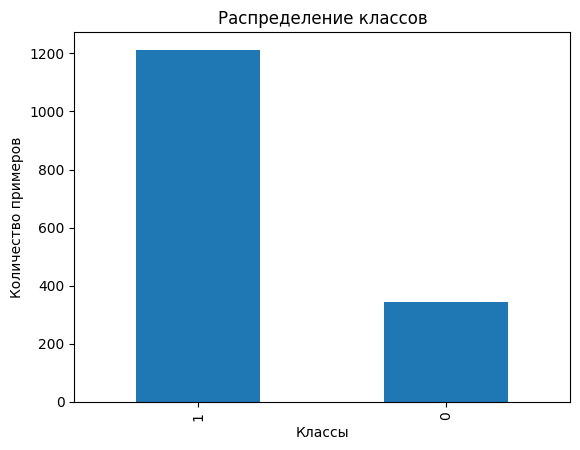

In [ ]:
target_column = 'isAlive'
class_counts = data[target_column].value_counts()
print(class_counts)


import matplotlib.pyplot as plt

class_counts.plot(kind='bar', title='Распределение классов')
plt.xlabel('Классы')
plt.ylabel('Количество примеров')
plt.show()
#целевая прееменная - категориальная

In [ ]:

categorical_columns = ['male', 'culture', 'house', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'isAlive', 'isPopular', 'boolDeadRelations' ]
categorical_features = data[categorical_columns]
categorical_features.columns
data_test

,male,culture,dateOfBirth,house,book1,book2,book3,book4,book5,isAliveMother,...,isMarried,isNoble,age,numDeadRelations,has_mother,has_father,has_heir,has_spouse,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
1558,0,Unknown,156.0,House Blackwood,0,0,0,0,1,False,...,0,0,100.0,0,0,0,0,1,0,0
1559,0,Asshai,267.0,R'hllor,0,1,1,1,1,False,...,0,0,32.0,0,0,0,0,1,1,0
1560,0,Unknown,267.0,Brotherhood without banners,0,0,1,1,0,False,...,0,0,32.0,0,0,0,0,1,0,0
1561,1,Unknown,267.0,House Trant,1,1,1,1,1,False,...,0,1,32.0,0,0,0,0,1,0,0
1562,1,Riverlands,262.0,House Frey,1,1,1,1,1,False,...,1,0,38.0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,1,Westeros,267.0,House Stark,1,1,1,1,1,False,...,0,0,32.0,0,0,0,0,1,0,0
1943,1,Unknown,267.0,House Bolton,0,1,0,1,1,False,...,0,0,32.0,0,0,0,0,1,0,0
1944,1,Unknown,267.0,Unknown,1,1,1,1,1,False,...,0,0,32.0,0,0,0,0,1,0,0


In [ ]:
import numpy as np
unique_count = data['culture'].nunique()
unique_count


52

In [ ]:
data_full = pd.concat([data, data_test], axis=0)
oho = OneHotEncoder(sparse_output=False)
oho.fit(data_full[['culture', 'house']])
data.reset_index(drop = True, inplace = True)
encoded_data = oho.transform(data[['culture', 'house']])
encoded_feature_names = oho.get_feature_names_out()
encoded_frame = pd.DataFrame(encoded_data, columns=encoded_feature_names)
frame_encoded = pd.concat([data, encoded_frame], axis=1)
frame_encoded.drop(columns=['culture', 'house'], inplace = True)

index = data_test.index
data_test.reset_index(drop = True, inplace = True)
encoded_data_test = oho.transform(data_test[['culture', 'house']])
encoded_frame_test = pd.DataFrame(encoded_data_test, columns=encoded_feature_names)
frame_encoded_test = pd.concat([data_test, encoded_frame_test], axis=1)
frame_encoded_test.drop(columns=['culture', 'house'], inplace = True)
frame_encoded_test




,male,dateOfBirth,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,...,house_Thenn,house_Thirteen,house_Three-eyed crow,house_Undying Ones,house_Unknown,house_Unsullied,house_Windblown,house_Wise Masters,house_brotherhood without banners,house_wildling
0,0,156.0,0,0,0,0,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,267.0,0,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,267.0,0,0,1,1,0,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,267.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,262.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,1,267.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
385,1,267.0,0,1,0,1,1,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
386,1,267.0,1,1,1,1,1,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
387,1,267.0,0,0,1,1,1,False,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
data['isAlive'].value_counts()

,count
isAlive,
1,1212
0,345


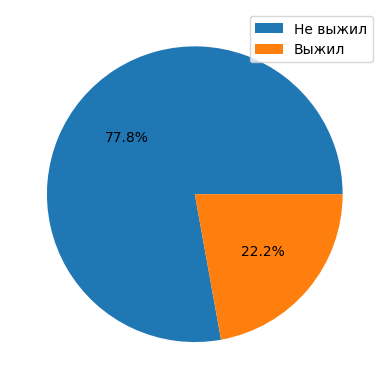

In [ ]:

graphic = data['isAlive'].value_counts()


plt.pie(graphic, autopct='%1.1f%%')

plt.legend(['Не выжил', 'Выжил'])

plt.show()

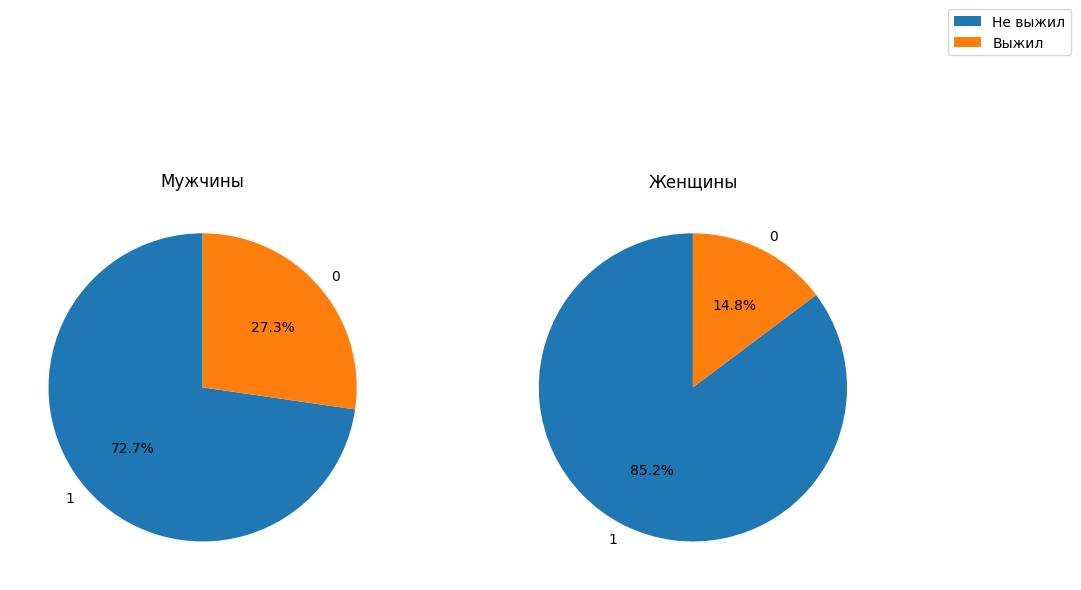

In [ ]:

data_male_survived = data[data['male'] == 1]['isAlive'].value_counts()
data_female_survived = data[data['male'] == 0]['isAlive'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(data_male_survived.values, labels=data_male_survived.index, autopct='%1.1f%%', startangle=90)
ax1.set_title("Мужчины")

ax2.pie(data_female_survived.values, labels=data_female_survived.index, autopct='%1.1f%%', startangle=90)
ax2.set_title("Женщины")

plt.legend(['Не выжил', 'Выжил'], loc='upper right', bbox_to_anchor=(1.5, 1.5))

plt.tight_layout()
plt.show()


In [ ]:
X = frame_encoded.drop(columns=['isAlive']).values
y = frame_encoded['isAlive'].values



In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [1]:
from sklearn.linear_model import LogisticRegression

In [2]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [3]:
len(X_train)
X_train.shape[1]

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Шаг 1. Создание модели
logistic_regression = LogisticRegression(C=1, max_iter=1000, random_state=42)

# Шаг 2. Обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

In [ ]:
random_forest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
svc_model = SVC(class_weight='balanced', probability=True, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
decision_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
gnb_model = GaussianNB()
ada_boost = AdaBoostClassifier(random_state=42)

random_forest.fit(X_train, y_train)
svc_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
gnb_model.fit(X_train, y_train)
ada_boost.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)
y_pred_rf = random_forest.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_gnb = gnb_model.predict(X_test)
y_pred_ada = ada_boost.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
accuracy_ada = accuracy_score(y_test, y_pred_ada)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pred = logistic_regression.predict(X_test)
y_pred = random_forest.predict(X_test)
y_pred_svc = svc_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_gnb = gnb_model.predict(X_test)
y_pred_ada = ada_boost.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
accuracy_ada = accuracy_score(y_test, y_pred_ada)

print("Accuracy : %.4f" % accuracy, accuracy_rf, accuracy_svc, accuracy_knn, accuracy_dt, accuracy_gnb, accuracy_ada)

Accuracy : 0.7981 0.7980769230769231 0.8397435897435898 0.8237179487179487 0.7596153846153846 0.3782051282051282 0.8397435897435898


In [ ]:
y_pred_test = knn_model.predict(frame_encoded_test)
y_pred_test
#лучшая модоль - KNN

NameError: name 'knn_model' is not defined

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.7MB/s]


In [ ]:
submission = pd.DataFrame(y_pred_test, columns=['isAlive'], index=index).reset_index()
submission


NameError: name 'y_pred_test' is not defined

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)

In [ ]:

submission1 = pd.read_csv("/content/new_submission.csv")
submission.to_csv("/content/new_submission.csv", index=False)


In [ ]:
frame_encoded_test